# ABLA — Controlled Ablation of Input Baseline Centering using `P + dP/dt`

This notebook tests one question: **How does primary-signal scaling affect multi-temperature
LOMO generalization and input-to-reservoir dynamics when the ESN input is fixed to `P + dP/dt`?**

Three otherwise identical pipelines are compared:

- **A — Not baseline-centered:** absolute smoothed `P`, followed by its derivative.
- **B — Baseline-centered:** `P(t)-P(0)`, followed by the derivative of that centered signal.
- **C — Per-trial normalized:** smoothed `P` is mapped so its maximum is 0 and minimum is −1,
  followed by the derivative of that normalized signal.

All cases use the same smoothing, 0–5 s window, summarized ESN trajectories, LOMO folds,
reservoir realizations, and fixed ESN–XGBoost hyperparameters. No `StandardScaler` is applied
after the condition-specific transformation. The XGBoost regressor receives **summarized ESN
features only**—no manually computed thermal features and no temperature predictor. No Bayesian
or Optuna search occurs.

# 1. Imports and fixed reference configuration

In [117]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


In [118]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 5.0)
# Predeclared semi-universal reference settings; these are not optimized here.
ESN_PARAMS = {
    "res_size": 20,
    "leak_rate": 0.30,
    "input_magnitude": 1.00,
    "spectral_radius": 0.90,
    "washout": 0,
}
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "min_child_weight": 5,
    "reg_alpha": 0.10,
    "reg_lambda": 10.0,
}
RESERVOIR_SEEDS = (42, 43, 44)
RANDOM_STATE = 42
CLIP_PREDICTIONS_TO_TRAIN_RANGE = True

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_STEM = "ABLA_three_primary_dprimary_scalings_direct_to_ESN_no_standard_scaler_fixed_HP_0to5_summarized_ESN_only_LOMO"

print("Fixed ESN HPs:", ESN_PARAMS)
print("Fixed XGBoost HPs:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)

Fixed ESN HPs: {'res_size': 20, 'leak_rate': 0.3, 'input_magnitude': 1.0, 'spectral_radius': 0.9, 'washout': 0}
Fixed XGBoost HPs: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 10.0}
Reservoir seeds: (42, 43, 44)


## Why these HPs are fixed

- **20 units:** enough nonlinear response modes while limiting dimensionality.
- **Leak rate 0.30:** moderate updating that balances responsiveness and memory.
- **Input magnitude 1.00:** a neutral fixed multiplier that exposes the consequences of each condition's actual numerical scale.
- **Spectral radius 0.90:** recurrent memory near but below the conventional stability boundary.
- **Washout 0:** contact is aligned to $t=0$ and the initial transient must be retained.
- **Three seeds:** reduces dependence on one random reservoir realization.
- **Shallow regularized XGBoost:** permits nonlinear relationships while discouraging excessive tree complexity.

# 2. Load trials and apply standard material properties

In [119]:
STANDARD_PROPERTIES = {
    "ps_foam":  {"k": 0.034, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":  {"k": 0.043, "rho": 30.0,   "cp": 1400.0},
    "cork":     {"k": 0.043, "rho": 240.0,  "cp": 1800.0},
    "wood":     {"k": 0.150, "rho": 700.0,  "cp": 1700.0},
    "pdms":     {"k": 0.150, "rho": 970.0,  "cp": 1460.0},
    "gypsum":   {"k": 0.170, "rho": 800.0,  "cp": 1090.0},
    "cement":   {"k": 0.290, "rho": 1440.0, "cp": 750.0},
    "graphite": {"k": 100.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":  {"k": 8.1,   "rho": 9780.0, "cp": 130.0},
    "titanium": {"k": 21.9,  "rho": 4506.0, "cp": 523.0},
    "nickel":   {"k": 90.9,  "rho": 8908.0, "cp": 461.0},
    "iron":     {"k": 80.4,  "rho": 7874.0, "cp": 449.0},
    "aluminum": {"k": 237.0, "rho": 2700.0, "cp": 897.0},
    "copper":   {"k": 401.0, "rho": 8960.0, "cp": 385.0},
}
SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum",
    "cement": "cement", "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            warnings.warn(f"Skipping {path.name}: missing required columns")
            continue
        frame["Temperature"] = temperature
        frames.append(frame)
if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(SAMPLE_ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError(f"Unknown materials: {sorted(normalized[DATA['Sample'].isna()].unique())}")
DATA["Temperature_C"] = pd.to_numeric(DATA["Temperature"].str.extract(r"(\d+)", expand=False))
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda material: STANDARD_PROPERTIES[material][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str))
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)
print(f"Loaded {DATA['trial_id'].nunique()} temperature-specific trials.")

Loaded 336 temperature-specific trials.


# 3. Detect contact and retain the common 0–5 s response

In [120]:
def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=0.30, skip_samples=5):
    clean = (trial[["Time", "Primary"]].dropna().sort_values("Time")
             .drop_duplicates("Time").reset_index(drop=True))
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid samples.")
    work_time, work_signal = time[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(work_signal))
    if window % 2 == 0: window -= 1
    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])

aligned_trials = {}
metadata_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: fewer than 10 retained samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    metadata_rows.append({
        "trial_id": trial_id, "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0], "Trial": int(trial["Trial"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
METADATA = pd.DataFrame(metadata_rows).sort_values("trial_id").reset_index(drop=True)
print(f"Aligned trials retained: {len(METADATA)}")
display(METADATA.groupby("Temperature").agg(trials=("trial_id", "size"), materials=("Sample", "nunique")))


Aligned trials retained: 336


,trials,materials
Temperature,,
30C,84,14
40C,84,14
50C,84,14
60C,84,14


# 4. Three condition-specific `P + dP/dt` representations

In [121]:
def smooth_signal(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= 5 else values.copy()
    )


def normalize_max_zero_min_minus_one(values):
    """Map one complete trial signal to [-1, 0]."""
    values = np.asarray(values, float)
    minimum, maximum = float(np.min(values)), float(np.max(values))
    span = maximum - minimum
    if not np.isfinite(span) or np.isclose(span, 0):
        raise ValueError("Cannot min–max normalize a constant or invalid primary signal.")
    return (values - maximum) / span


CONDITIONS = {
    "A_not_baseline_centered": "raw",
    "B_baseline_centered": "baseline_centered",
    "C_per_trial_minmax_-1_to_0": "minmax_-1_to_0",
}


def esn_input(trial, input_mode):
    """Create exactly two channels: transformed P, then d(transformed P)/dt."""
    time = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])

    if input_mode == "baseline_centered":
        represented_primary = primary - primary[0]
    elif input_mode == "minmax_-1_to_0":
        represented_primary = normalize_max_zero_min_minus_one(primary)
    elif input_mode == "raw":
        represented_primary = primary
    else:
        raise ValueError(f"Unknown input mode: {input_mode}")

    represented_rate = np.gradient(represented_primary, time)
    return np.column_stack([represented_primary, represented_rate])


# Auditable mathematical consequences of the transformation order:
# A and B have the same derivative because subtracting a constant does not change dP/dt.
# C rescales both P and dP/dt by the inverse within-trial primary range.

# 5. Fixed reservoir and nonredundant trajectory summaries

In [122]:
class ManualReservoir:
    def __init__(self, random_state):
        self.res_size = ESN_PARAMS["res_size"]
        self.leak_rate = ESN_PARAMS["leak_rate"]
        self.washout = ESN_PARAMS["washout"]
        rng = np.random.default_rng(random_state)
        # One bias column + exactly two input columns: P and dP/dt.
        self.Win = (rng.random((self.res_size, 3)) - 0.5) * ESN_PARAMS["input_magnitude"]
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        self.W = (W / radius.real) * ESN_PARAMS["spectral_radius"]

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 2:
            raise ValueError("Expected exactly two ESN inputs: P and dP/dt.")
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            proposed = np.tanh(self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x)
            x = (1-self.leak_rate)*x + self.leak_rate*proposed
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def summarize_states(time, states):
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    output = {}
    for unit in range(states.shape[1]):
        x = states[:, unit]
        prefix = f"esn_u{unit:03d}"
        output[f"{prefix}_mean"] = float(np.mean(x))
        output[f"{prefix}_std"] = float(np.std(x))
        output[f"{prefix}_min"] = float(np.min(x))
        output[f"{prefix}_max"] = float(np.max(x))
        output[f"{prefix}_initial"] = float(x[0])
        output[f"{prefix}_net_change"] = float(x[-1] - x[0])
        output[f"{prefix}_slope"] = float(np.polyfit(time, x, 1)[0])
        output[f"{prefix}_mean_abs"] = float(np.mean(np.abs(x)))
        output[f"{prefix}_abs_auc"] = float(np.trapezoid(np.abs(x), time))
    return output


print(f"ESN summary predictors per seed: {ESN_PARAMS['res_size'] * 9}")
print("ESN input dimensions: 2 (transformed P and its first derivative)")

ESN summary predictors per seed: 180
ESN input dimensions: 2 (transformed P and its first derivative)


## 5A. Same-trial visual comparison of Conditions A, B and C

This diagnostic passes the **same material, temperature and repetition** through each scaling
condition. The upper row shows the two values supplied to the ESN; the lower row shows the
resulting activations of matched reservoir units. Each condition has its own vertical scale
because their numerical magnitudes differ substantially. This visualizes preprocessing and
reservoir response—not predictive superiority.

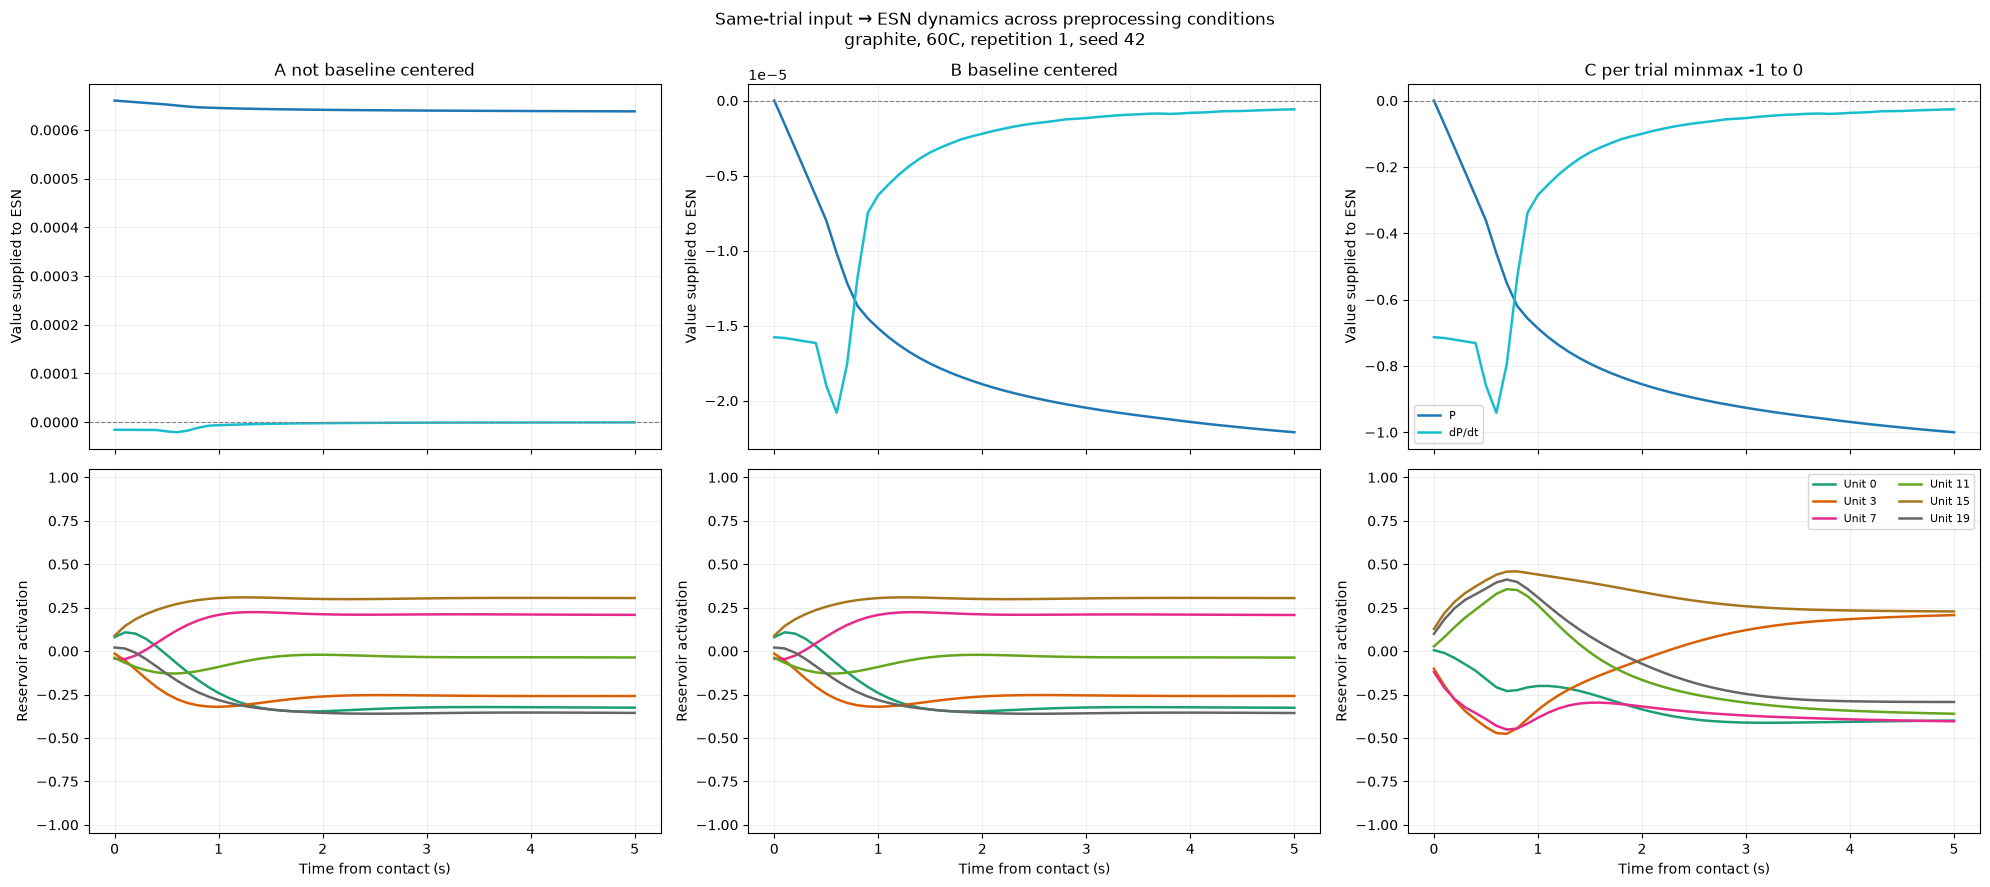

Example trial: 60C__graphite_trial_1
Interpretation reminder: the same reservoir is used in every column; only the input representation changes.


In [123]:
# Customize this example without rerunning the LOMO evaluation.
CONDITION_EXAMPLE_MATERIAL = "graphite"
CONDITION_EXAMPLE_TEMPERATURE = "60C"
CONDITION_EXAMPLE_TRIAL = 1
CONDITION_EXAMPLE_SEED = 42
CONDITION_EXAMPLE_UNITS = (0, 3, 7, 11, 15, 19)

selection = METADATA[
    (METADATA["Sample"] == CONDITION_EXAMPLE_MATERIAL)
    & (METADATA["Temperature"] == CONDITION_EXAMPLE_TEMPERATURE)
    & (METADATA["Trial"] == CONDITION_EXAMPLE_TRIAL)
]
if selection.empty:
    available = (
        METADATA[["Sample", "Temperature", "Trial"]]
        .drop_duplicates().sort_values(["Sample", "Temperature", "Trial"])
    )
    raise KeyError(
        "Requested example trial was not found. Available selections include:\n"
        + available.head(25).to_string(index=False)
    )

example_trial_id = selection.iloc[0]["trial_id"]
example_trial = aligned_trials[example_trial_id]
example_time = example_trial["time_from_contact"].to_numpy(float)

input_names = ("P", "dP/dt")
input_colors = plt.cm.tab10(np.linspace(0, 1, len(input_names)))
unit_colors = plt.cm.Dark2(np.linspace(0, 1, len(CONDITION_EXAMPLE_UNITS)))

fig, axes = plt.subplots(
    2, len(CONDITIONS), figsize=(20, 9), sharex="col", squeeze=False
)

for column, (condition, input_mode) in enumerate(CONDITIONS.items()):
    sequence = esn_input(example_trial, input_mode)
    reservoir = ManualReservoir(CONDITION_EXAMPLE_SEED)
    states = reservoir.run(sequence)
    state_time = example_time[ESN_PARAMS["washout"]:]

    for channel, name in enumerate(input_names):
        axes[0, column].plot(
            example_time, sequence[:, channel],
            color=input_colors[channel], linewidth=1.8, label=name,
        )
    axes[0, column].axhline(0, color="gray", linestyle="--", linewidth=.8)
    axes[0, column].set_title(condition.replace("_", " "))
    axes[0, column].set_ylabel("Value supplied to ESN")
    axes[0, column].grid(alpha=.20)

    for unit_index, unit in enumerate(CONDITION_EXAMPLE_UNITS):
        if unit >= states.shape[1]:
            raise IndexError(
                f"Requested Unit {unit}, but the reservoir has {states.shape[1]} units."
            )
        axes[1, column].plot(
            state_time, states[:, unit],
            color=unit_colors[unit_index], linewidth=1.8, label=f"Unit {unit}",
        )
    axes[1, column].set_xlabel("Time from contact (s)")
    axes[1, column].set_ylabel("Reservoir activation")
    axes[1, column].set_ylim(-1.05, 1.05)
    axes[1, column].grid(alpha=.20)

axes[0, -1].legend(fontsize=8, loc="best")
axes[1, -1].legend(fontsize=8, ncol=2, loc="best")
fig.suptitle(
    "Same-trial input → ESN dynamics across preprocessing conditions\n"
    f"{CONDITION_EXAMPLE_MATERIAL}, {CONDITION_EXAMPLE_TEMPERATURE}, "
    f"repetition {CONDITION_EXAMPLE_TRIAL}, seed {CONDITION_EXAMPLE_SEED}"
)
plt.tight_layout()
plt.show()

print("Example trial:", example_trial_id)
print(
    "Interpretation reminder: the same reservoir is used in every column; "
    "only the input representation changes."
)

# 6. Leakage-safe paired LOMO evaluation

No input scaler is fitted. After common smoothing, each condition supplies exactly two channels
to the fixed reservoir: its transformed `P` and the derivative calculated from that transformed
signal. All three conditions use the same held-out-material folds, reservoir matrices, state
summaries, and regressor settings.

In [124]:
def make_regressor(random_state):
    xgb = XGBRegressor(
        objective="reg:squarederror", random_state=int(random_state),
        n_jobs=-1, tree_method="hist", verbosity=0, **XGB_PARAMS,
    )
    base = Pipeline([("imputer", SimpleImputer(strategy="median")), ("xgb", xgb)])
    return TransformedTargetRegressor(
        regressor=base, func=np.log1p, inverse_func=np.expm1, check_inverse=False
    )

def pooled_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    target_range = float(np.ptp(y_true))
    return {
        "n": len(y_true), "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse, "nrmse_range": rmse/target_range,
        "r2": float(r2_score(y_true, y_pred)),
        "median_ape_pct": float(np.median(np.abs((y_true-y_pred)/y_true))*100),
    }

def feature_table(train_ids, all_ids, input_mode, seed):
    # train_ids is retained in the API to keep fold construction explicit,
    # but no scaler is fitted: each condition enters the ESN directly.
    reservoir = ManualReservoir(seed)
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = esn_input(trial, input_mode)
        states = reservoir.run(sequence)
        time = trial["time_from_contact"].to_numpy(float)[ESN_PARAMS["washout"]:]
        row = summarize_states(time, states)
        row["trial_id"] = trial_id
        rows.append(row)
    return pd.DataFrame(rows).set_index("trial_id")

logo = LeaveOneGroupOut()
prediction_rows, fold_rows = [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(METADATA, groups=METADATA["Sample"]), start=1):
    train_meta, test_meta = METADATA.iloc[train_idx], METADATA.iloc[test_idx]
    train_ids, test_ids = train_meta["trial_id"].tolist(), test_meta["trial_id"].tolist()
    y_train, y_test = train_meta[TARGET].to_numpy(float), test_meta[TARGET].to_numpy(float)
    material = test_meta["Sample"].iloc[0]
    print(f"Fold {fold:02d}/14: held out {material}")

    for condition, input_mode in CONDITIONS.items():
        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = feature_table(train_ids, train_ids + test_ids, input_mode, seed)
            X_train = features.loc[train_ids].reset_index(drop=True)
            X_test = features.loc[test_ids].reset_index(drop=True)
            model = make_regressor(seed)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                pred = np.clip(pred, y_train.min(), y_train.max())
            seed_predictions.append(pred)
        prediction = np.mean(seed_predictions, axis=0)
        residual = prediction - y_test
        rmse = float(np.sqrt(np.mean(residual**2)))
        fold_rows.append({
            "condition": condition, "fold": fold, "held_out_material": material,
            "n": len(y_test), "mae": float(np.mean(np.abs(residual))), "rmse": rmse,
            "nrmse_training_range": rmse/float(np.ptp(y_train)),
            "mean_error_bias": float(np.mean(residual)),
            "median_ape_pct": float(np.median(np.abs(residual/y_test))*100),
        })
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            prediction_rows.append({
                "condition": condition, "fold": fold, "trial_id": meta_row["trial_id"],
                "Temperature": meta_row["Temperature"], "Sample": meta_row["Sample"],
                "Trial": meta_row["Trial"], "y_true": y_test[row_index],
                "y_pred": prediction[row_index],
            })

OOF = pd.DataFrame(prediction_rows)
FOLD_METRICS = pd.DataFrame(fold_rows)
OVERALL = pd.DataFrame([
    {"condition": condition, **pooled_metrics(part["y_true"], part["y_pred"])}
    for condition, part in OOF.groupby("condition", sort=False)
])
display(OVERALL)


Fold 01/14: held out aluminum
Fold 02/14: held out bismuth
Fold 03/14: held out cement
Fold 04/14: held out copper
Fold 05/14: held out cork
Fold 06/14: held out graphite
Fold 07/14: held out gypsum
Fold 08/14: held out iron
Fold 09/14: held out nickel
Fold 10/14: held out pdms
Fold 11/14: held out ps_foam
Fold 12/14: held out pu_foam
Fold 13/14: held out titanium
Fold 14/14: held out wood


,condition,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,A_not_baseline_centered,336,4441.609149,8046.209785,0.216540,0.484640,55.364513
1,B_baseline_centered,336,5216.336395,9106.353232,0.245070,0.339889,65.245644
2,C_per_trial_minmax_-1_to_0,336,5128.706170,8917.266081,0.239982,0.367018,61.156983


# 7. Paired performance comparison

rmse                      \
condition         A_not_baseline_centered B_baseline_centered   
held_out_material                                               
cement                        2309.069244         1026.481195   
graphite                      4925.662958         4859.804171   
ps_foam                        136.884942          135.316798   
pdms                           225.834569          242.151197   
cork                           141.078555          192.303974   
gypsum                        1394.174045         1687.010849   
titanium                      6035.783848         6525.866818   
pu_foam                        346.578903         1528.406449   
iron                          4534.493304         5749.331568   
bismuth                       9882.604626        11612.855536   
nickel                        4322.652653         6603.095447   
aluminum                     10464.729013        13045.936873   
copper                       24285.545868        26011.946624   
wood                          1411.255610         5483.901648   

                                                nrmse_training_range  \
condition         C_per_trial_minmax_-1_to_0 A_not_baseline_centered   
held_out_material                                                      
cement                            211.972993                0.062142   
graphite                         8068.196097                0.132560   
ps_foam                           118.833706                0.003685   
pdms                             1147.069123                0.006078   
cork                              332.800120                0.003797   
gypsum                            306.736066                0.037520   
titanium                         8753.132203                0.162435   
pu_foam                           800.487204                0.009327   
iron                             5480.498370                0.122032   
bismuth                         10601.720368                0.265961   
nickel                           7904.911328                0.116331   
aluminum                        10544.216999                0.281627   
copper                          25556.061858                1.015129   
wood                              317.104075                0.037980   

                                                                  \
condition         B_baseline_centered C_per_trial_minmax_-1_to_0   
held_out_material                                                  
cement                       0.027625                   0.005705   
graphite                     0.130787                   0.217132   
ps_foam                      0.003642                   0.003199   
pdms                         0.006517                   0.030870   
cork                         0.005175                   0.008956   
gypsum                       0.045401                   0.008255   
titanium                     0.175624                   0.235565   
pu_foam                      0.041133                   0.021543   
iron                         0.154726                   0.147491   
bismuth                      0.312526                   0.285314   
nickel                       0.177703                   0.212737   
aluminum                     0.351093                   0.283766   
copper                       1.087292                   1.068237   
wood                         0.147583                   0.008534   

                           median_ape_pct                      \
condition         A_not_baseline_centered B_baseline_centered   
held_out_material                                               
cement                          39.970534           65.202889   
graphite                        28.865428           34.517152   
ps_foam                        108.533672          366.747391   
pdms                            48.064227           44.770274   
cork                            70.383820           67.179925   
gypsum                       

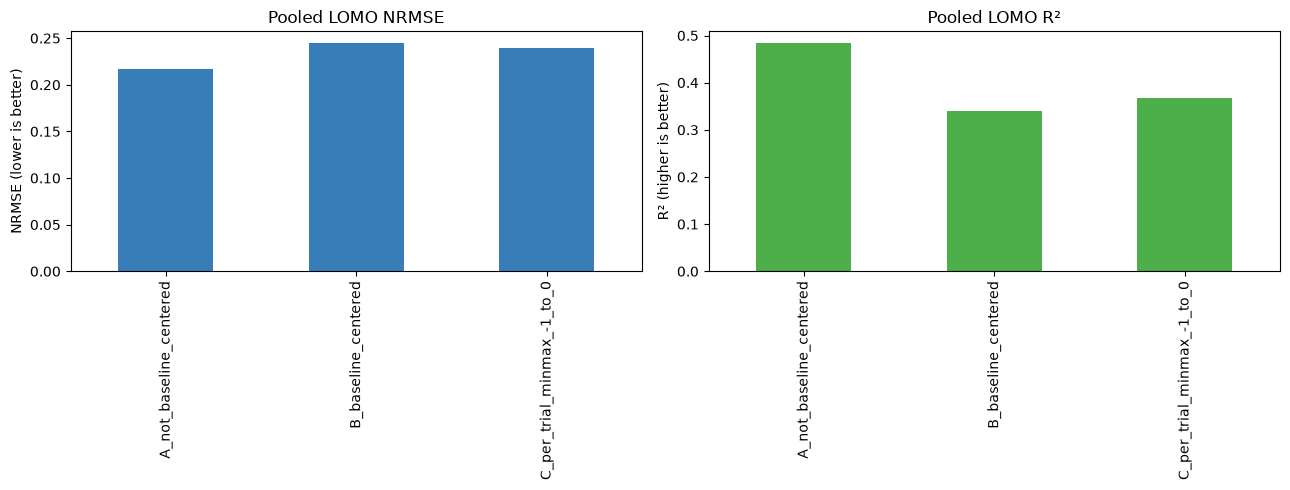

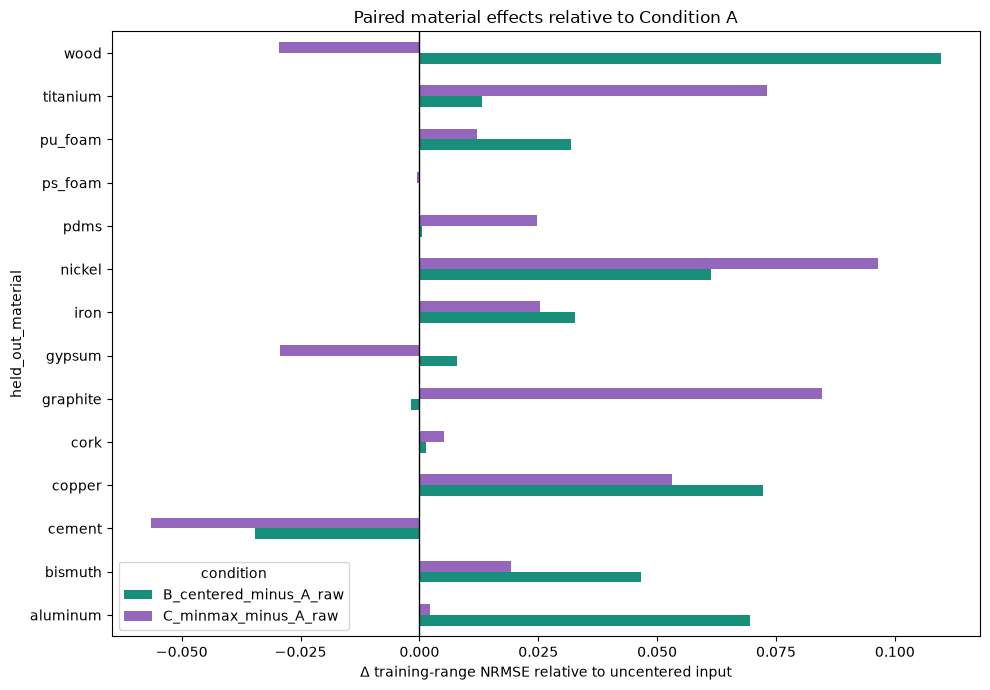

Negative Δ means that preprocessing condition improved the held-out material relative to Condition A.


In [125]:
paired_folds = FOLD_METRICS.pivot(index="held_out_material", columns="condition", values=["rmse", "nrmse_training_range", "median_ape_pct"])
paired_folds[("delta", "B_centered_minus_A_raw")] = (
    paired_folds[("nrmse_training_range", "B_baseline_centered")]
    - paired_folds[("nrmse_training_range", "A_not_baseline_centered")]
)
paired_folds[("delta", "C_minmax_minus_A_raw")] = (
    paired_folds[("nrmse_training_range", "C_per_trial_minmax_-1_to_0")]
    - paired_folds[("nrmse_training_range", "A_not_baseline_centered")]
)
display(paired_folds.sort_values(("delta", "B_centered_minus_A_raw")))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
summary_plot = OVERALL.set_index("condition")
summary_plot[["nrmse_range"]].plot(kind="bar", legend=False, ax=axes[0], color="#377eb8")
axes[0].set(title="Pooled LOMO NRMSE", ylabel="NRMSE (lower is better)", xlabel="")
summary_plot[["r2"]].plot(kind="bar", legend=False, ax=axes[1], color="#4daf4a")
axes[1].set(title="Pooled LOMO R²", ylabel="R² (higher is better)", xlabel="")
plt.tight_layout(); plt.show()

deltas = paired_folds["delta"].sort_index()
ax = deltas.plot(kind="barh", figsize=(10, 7), color=["#188F7A", "#9467bd"])
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Paired material effects relative to Condition A", xlabel="Δ training-range NRMSE relative to uncentered input")
plt.tight_layout(); plt.show()
print("Negative Δ means that preprocessing condition improved the held-out material relative to Condition A.")


# 8. Input-to-dynamics comparison using all repetitions

Choose one material and temperature. Every available repetition is transformed and passed through the reservoir independently. The same input channel or reservoir unit is then averaged across repetitions, and the shaded region shows ±1 repetition SD. Trials are never averaged before the nonlinear ESN transformation.

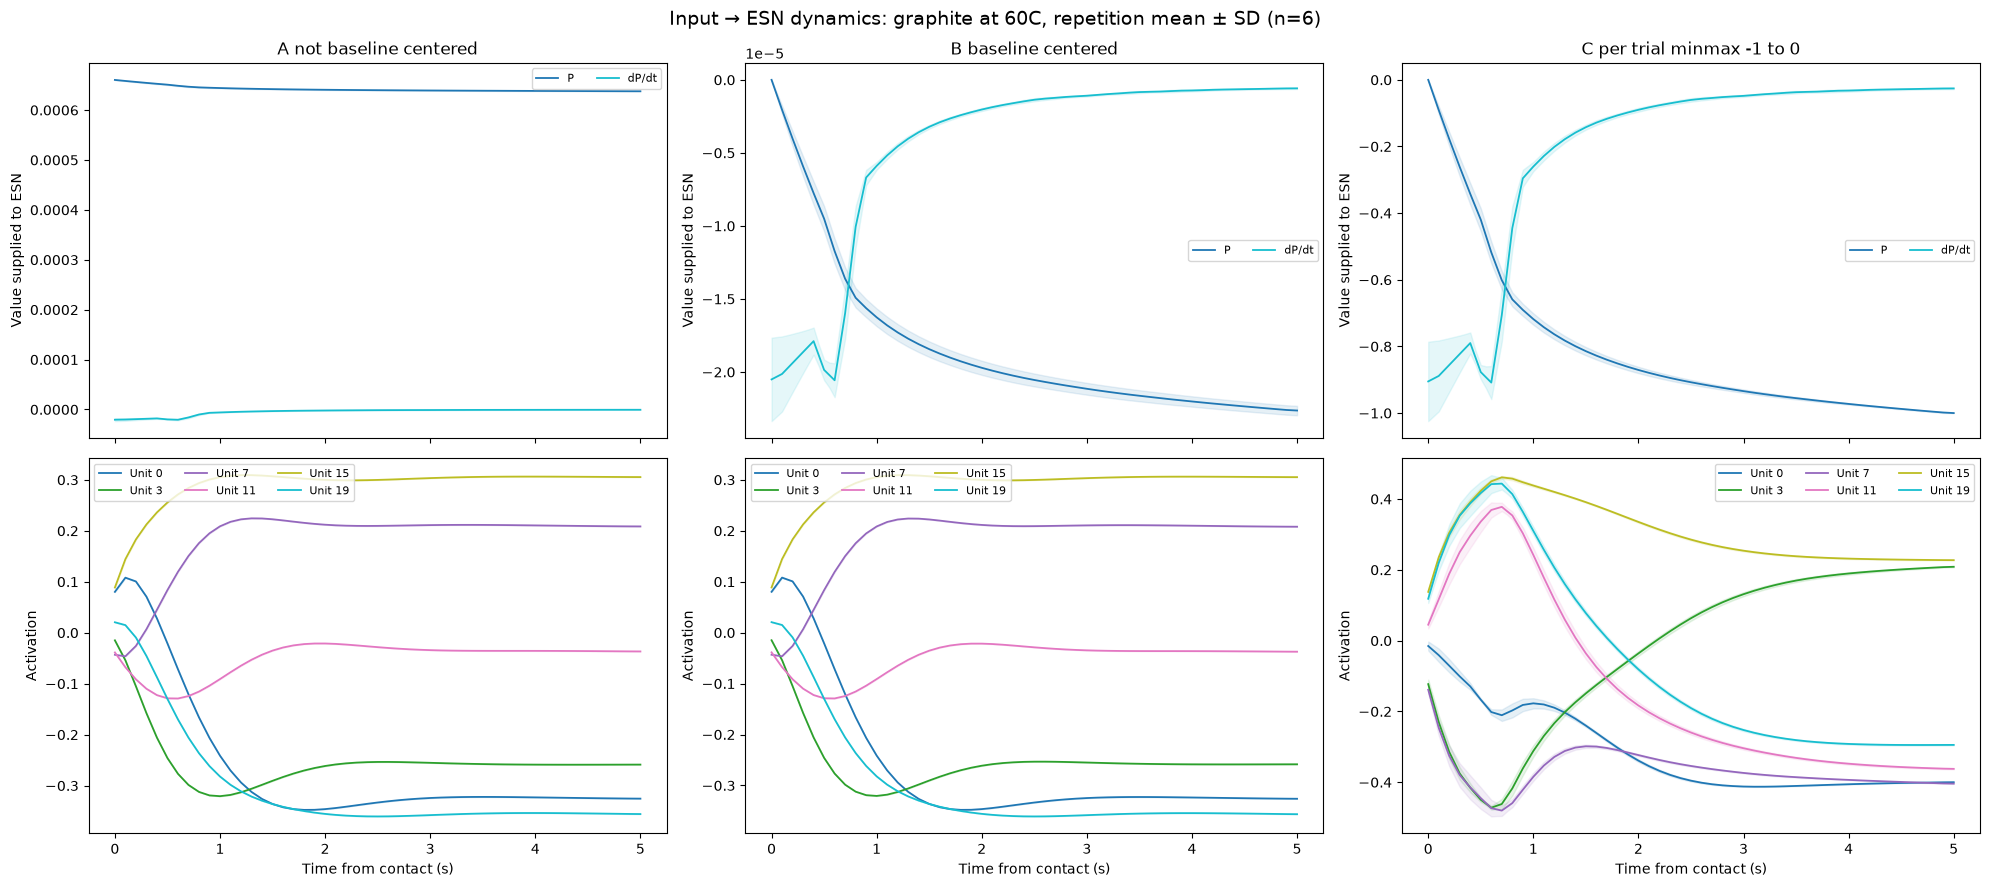

,condition,n_repetitions,mean_rms_activation_mean,mean_rms_activation_sd,mean_absolute_activation_mean,mean_absolute_activation_sd,fraction_near_saturation_abs_gt_0.95_mean,fraction_near_saturation_abs_gt_0.95_sd
0,A_not_baseline_centered,6,0.286510,0.000161,0.250432,0.000136,0.0,0.0
1,B_baseline_centered,6,0.286619,0.000162,0.250517,0.000137,0.0,0.0
2,C_per_trial_minmax_-1_to_0,6,0.420522,0.002745,0.365712,0.002335,0.0,0.0


In [126]:
DIAGNOSTIC_MATERIAL = "graphite"
DIAGNOSTIC_TEMPERATURE = "60C"
DIAGNOSTIC_SEED = 42
REPRESENTATIVE_UNITS = (0, 3, 7, 11, 15, 19)
DIAGNOSTIC_GRID_POINTS = 101

selected = (METADATA[(METADATA["Sample"] == DIAGNOSTIC_MATERIAL)
                     & (METADATA["Temperature"] == DIAGNOSTIC_TEMPERATURE)]
            .sort_values("Trial"))
if selected.empty:
    raise KeyError("The requested diagnostic material and temperature were not found.")
selected_ids = selected["trial_id"].tolist()
common_time = np.linspace(ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1], DIAGNOSTIC_GRID_POINTS)

# Process every repetition independently before averaging.
diagnostics = {}
for condition, input_mode in CONDITIONS.items():
    reservoir = ManualReservoir(DIAGNOSTIC_SEED)
    repetition_inputs = []
    repetition_states = []
    repetition_activity = []
    for trial_id in selected_ids:
        trial = aligned_trials[trial_id]
        original_time = trial["time_from_contact"].to_numpy(float)
        represented = esn_input(trial, input_mode)
        states = reservoir.run(represented)
        repetition_inputs.append(np.column_stack([
            np.interp(common_time, original_time, represented[:, channel])
            for channel in range(represented.shape[1])
        ]))
        repetition_states.append(np.column_stack([
            np.interp(common_time, original_time, states[:, unit])
            for unit in range(states.shape[1])
        ]))
        repetition_activity.append({
            "mean_rms_activation": float(np.mean(np.sqrt(np.mean(states**2, axis=1)))),
            "mean_absolute_activation": float(np.mean(np.abs(states))),
            "fraction_near_saturation_abs_gt_0.95": float(np.mean(np.abs(states) > 0.95)),
        })
    input_stack = np.asarray(repetition_inputs)
    state_stack = np.asarray(repetition_states)
    diagnostics[condition] = {
        "input_mean": input_stack.mean(axis=0),
        "input_sd": input_stack.std(axis=0, ddof=1),
        "state_mean": state_stack.mean(axis=0),
        "state_sd": state_stack.std(axis=0, ddof=1),
        "activity_by_repetition": pd.DataFrame(repetition_activity),
    }

fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharex=True)
channel_names = ["P", "dP/dt"]
channel_colors = plt.cm.tab10(np.linspace(0, 1, len(channel_names)))
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(REPRESENTATIVE_UNITS)))
for column, (condition, values) in enumerate(diagnostics.items()):
    for channel, name in enumerate(channel_names):
        mean = values["input_mean"][:, channel]
        sd = values["input_sd"][:, channel]
        color = channel_colors[channel]
        axes[0, column].plot(common_time, mean, color=color, label=name, linewidth=1.3)
        axes[0, column].fill_between(common_time, mean-sd, mean+sd, color=color, alpha=0.11)
    axes[0, column].set(title=condition.replace("_", " "), ylabel="Value supplied to ESN")
    axes[0, column].legend(fontsize=8, ncol=2)
    for unit_index, unit in enumerate(REPRESENTATIVE_UNITS):
        mean = values["state_mean"][:, unit]
        sd = values["state_sd"][:, unit]
        color = unit_colors[unit_index]
        axes[1, column].plot(common_time, mean, color=color, linewidth=1.3, label=f"Unit {unit}")
        axes[1, column].fill_between(common_time, mean-sd, mean+sd, color=color, alpha=0.11)
    axes[1, column].set(xlabel="Time from contact (s)", ylabel="Activation")
    axes[1, column].legend(fontsize=8, ncol=3)
fig.suptitle(
    f"Input → ESN dynamics: {DIAGNOSTIC_MATERIAL} at {DIAGNOSTIC_TEMPERATURE}, "
    f"repetition mean ± SD (n={len(selected_ids)})", fontsize=14,
)
plt.tight_layout(); plt.show()

activity_rows = []
for condition, values in diagnostics.items():
    per_repetition = values["activity_by_repetition"]
    row = {"condition": condition, "n_repetitions": len(per_repetition)}
    for metric in per_repetition.columns:
        row[f"{metric}_mean"] = float(per_repetition[metric].mean())
        row[f"{metric}_sd"] = float(per_repetition[metric].std(ddof=1))
    activity_rows.append(row)
display(pd.DataFrame(activity_rows))

# 9. Actual-versus-predicted and material-mean behavior

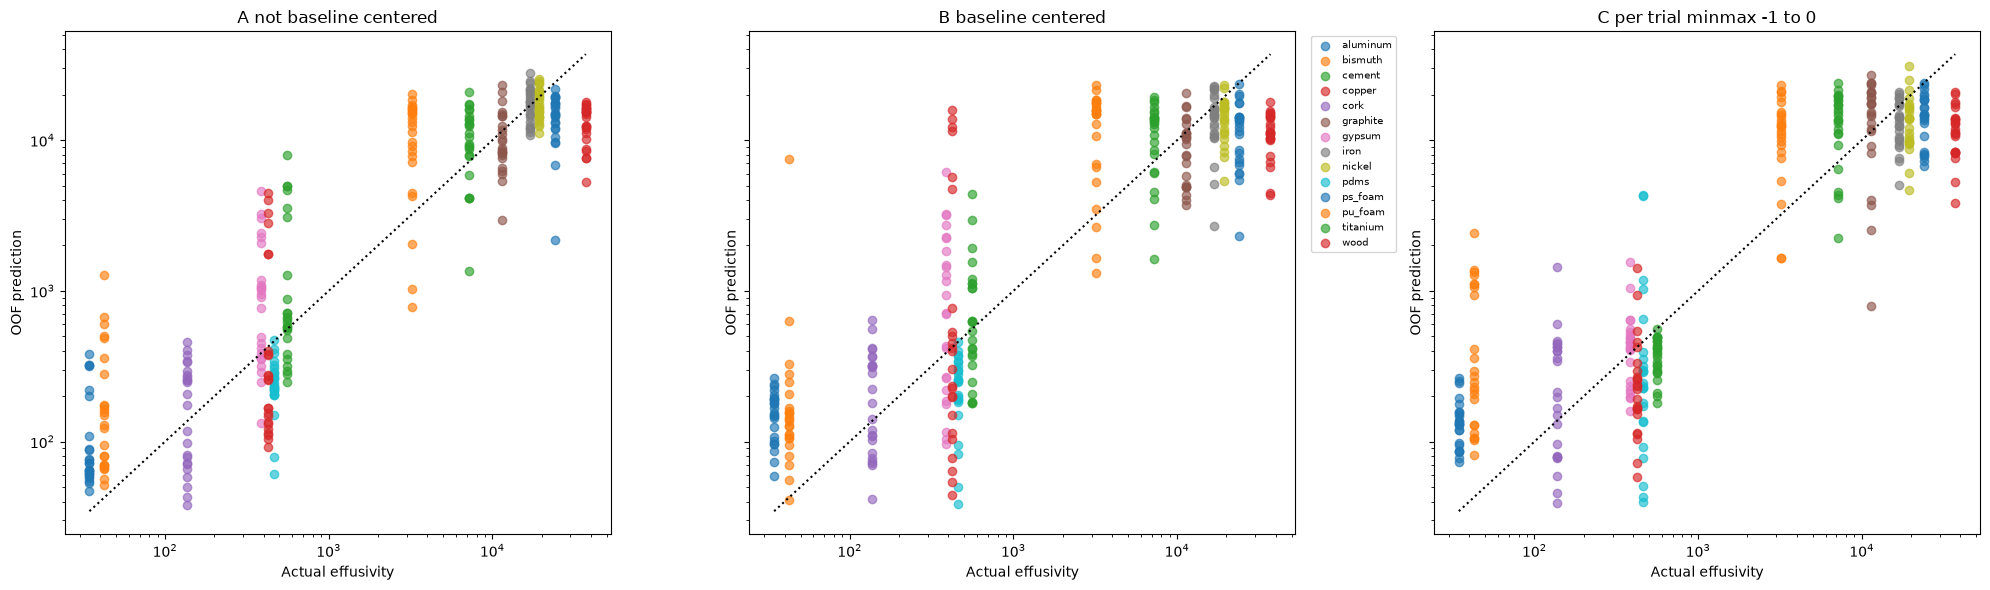

LOMO performance after averaging 24 OOF trials per material:


,condition,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,A_not_baseline_centered,14,3632.058068,7326.343358,0.197167,0.572730,57.815584
1,B_baseline_centered,14,4678.864413,8287.788491,0.223041,0.453229,66.895508
2,C_per_trial_minmax_-1_to_0,14,4532.573615,7990.856372,0.215050,0.491706,38.011418


In [127]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
for ax, (condition, part) in zip(axes, OOF.groupby("condition", sort=False)):
    for material, material_part in part.groupby("Sample"):
        ax.scatter(material_part["y_true"], material_part["y_pred"], alpha=0.65, label=material)
    low = min(part["y_true"].min(), part["y_pred"].min())
    high = max(part["y_true"].max(), part["y_pred"].max())
    ax.plot([low, high], [low, high], "k:")
    ax.set(xscale="log", yscale="log", title=condition.replace("_", " "), xlabel="Actual effusivity", ylabel="OOF prediction")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

MATERIAL_MEANS = OOF.groupby(["condition", "Sample"], as_index=False).agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"), prediction_sd=("y_pred", "std"), n=("trial_id", "size"))
MATERIAL_LEVEL_RESULTS = pd.DataFrame([
    {"condition": condition, **pooled_metrics(part["y_true"], part["y_pred"])}
    for condition, part in MATERIAL_MEANS.groupby("condition", sort=False)
])
print("LOMO performance after averaging 24 OOF trials per material:")
display(MATERIAL_LEVEL_RESULTS)


# 10. Selected-material input → ESN dynamics → LOMO OOF correspondence

This reproduces the correspondence presentation for any preprocessing condition. Each material
block shows actual and OOF-predicted effusivity, the condition-specific `P + dP/dt` representation,
and representative reservoir trajectories. Lines are repetition means and shading is ±1 SD.

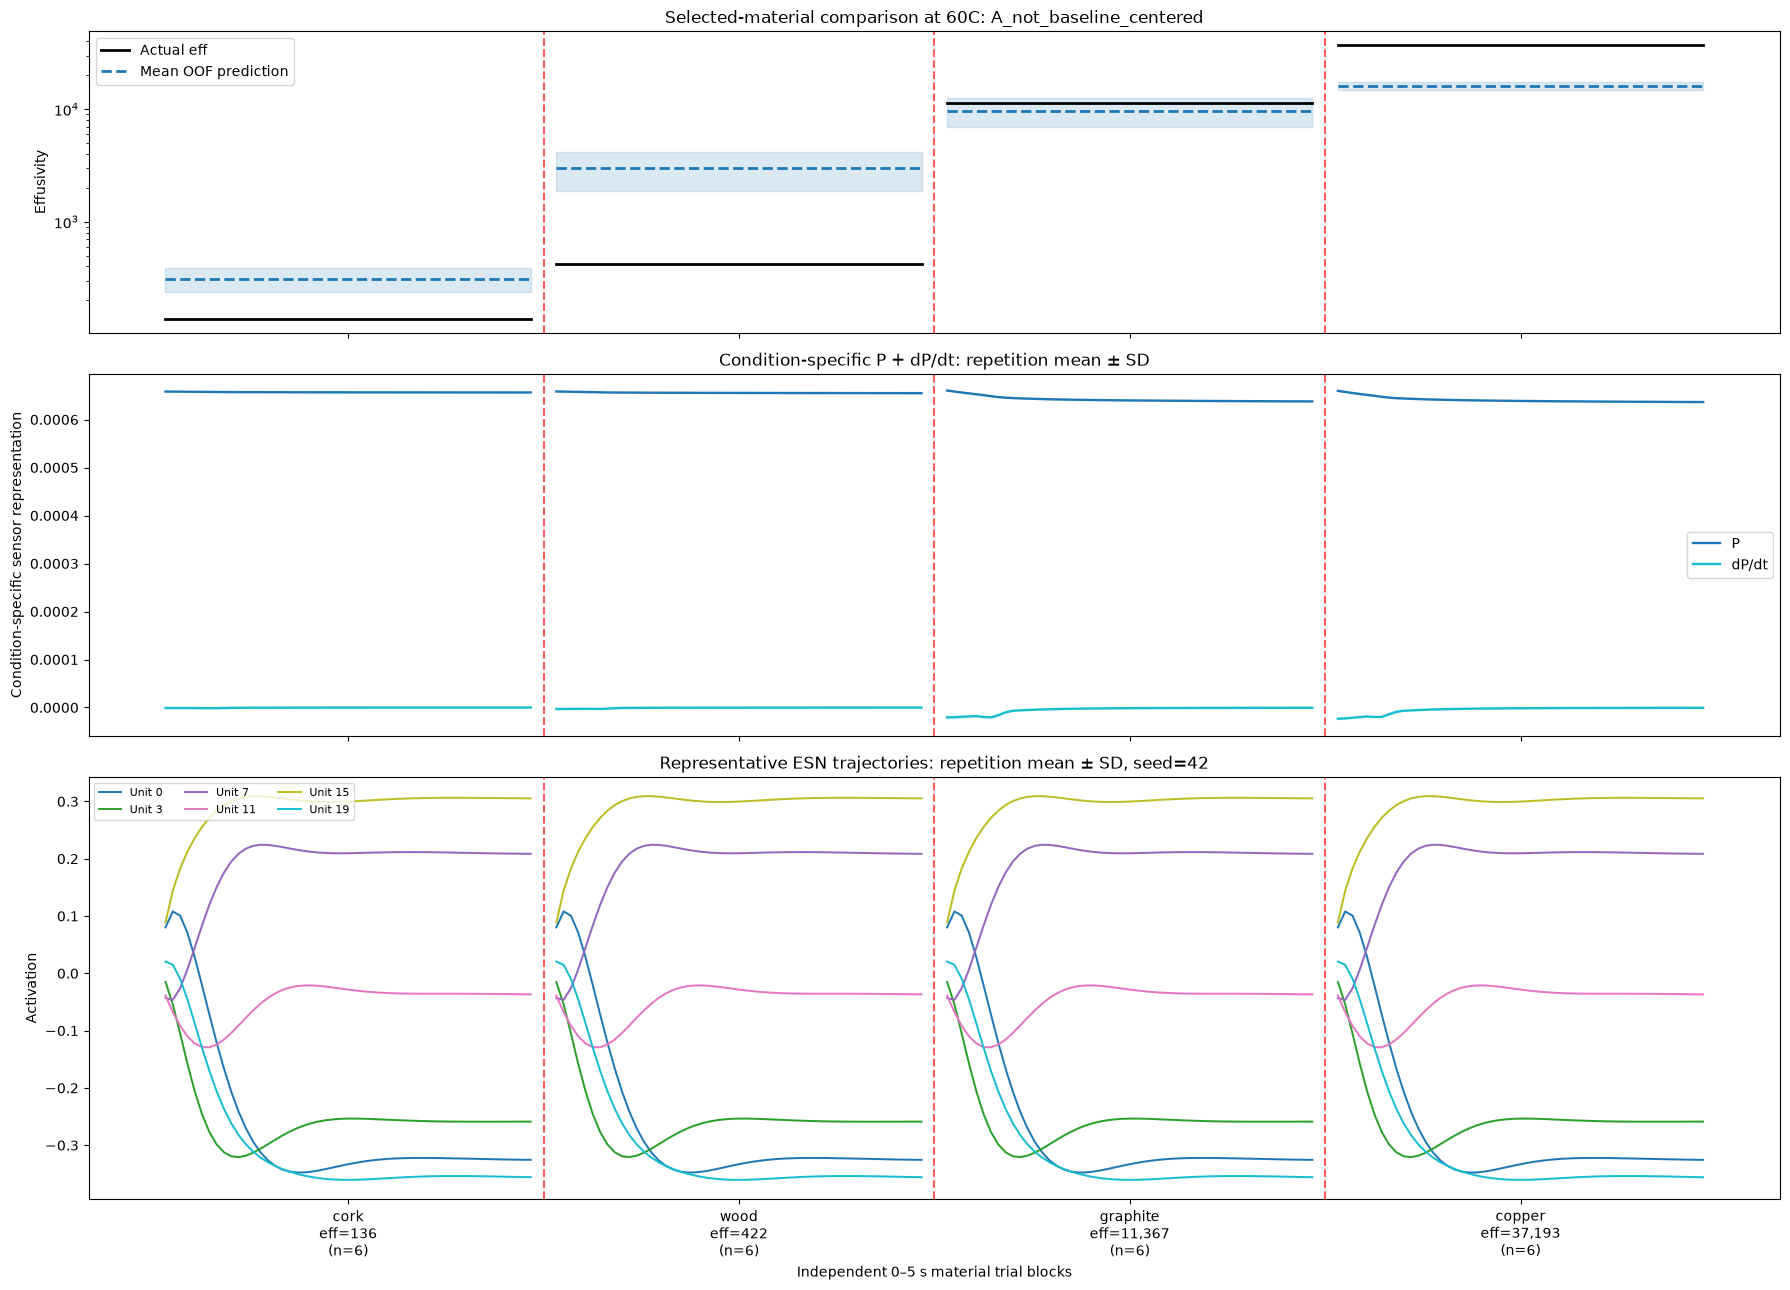

In [131]:
CONDITIONS = {
    "A_not_baseline_centered": "raw",
    "B_baseline_centered": "baseline_centered",
    "C_per_trial_minmax_-1_to_0": "minmax_-1_to_0",
}

CASE_STUDY_CONDITION = "A_not_baseline_centered"  # choose any key in CONDITIONS
CASE_STUDY_TEMPERATURE = "60C"
CASE_STUDY_MATERIALS = ["cork", "wood", "graphite", "copper"]
CASE_STUDY_SEED = 42
CASE_STUDY_UNITS = (0, 3, 7, 11, 15, 19)
CASE_STUDY_GRID_POINTS = 101

if CASE_STUDY_CONDITION not in CONDITIONS:
    raise KeyError(f"Unknown condition. Choose from {list(CONDITIONS)}")
case_mode = CONDITIONS[CASE_STUDY_CONDITION]
case_grid = np.linspace(*ANALYSIS_WINDOW, CASE_STUDY_GRID_POINTS)
block_length = ANALYSIS_WINDOW[1] - ANALYSIS_WINDOW[0]
gap = 0.35

fig, axes = plt.subplots(3, 1, figsize=(18, 13), sharex=True, gridspec_kw={"height_ratios": [1.0, 1.2, 1.4]})
material_labels = []
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(CASE_STUDY_UNITS)))
for block, material in enumerate(CASE_STUDY_MATERIALS):
    selected_meta = METADATA[(METADATA["Sample"] == material) & (METADATA["Temperature"] == CASE_STUDY_TEMPERATURE)].sort_values("Trial")
    if selected_meta.empty:
        warnings.warn(f"No trials found for {material} at {CASE_STUDY_TEMPERATURE}")
        continue
    selected_ids = selected_meta["trial_id"].tolist()
    x_offset = block * (block_length + gap)
    x = x_offset + case_grid

    # Trial-level LOMO predictions already produced by the paired evaluation.
    prediction_part = OOF[(OOF["condition"] == CASE_STUDY_CONDITION) & (OOF["Sample"] == material) & (OOF["Temperature"] == CASE_STUDY_TEMPERATURE)]
    actual = float(selected_meta[TARGET].iloc[0])
    predicted_mean = float(prediction_part["y_pred"].mean())
    predicted_sd = float(prediction_part["y_pred"].std(ddof=1))
    axes[0].plot([x[0], x[-1]], [actual, actual], color="black", linewidth=2.0, label="Actual eff" if block == 0 else None)
    axes[0].plot([x[0], x[-1]], [predicted_mean, predicted_mean], color="#1f77b4", linestyle="--", linewidth=2.0, label="Mean OOF prediction" if block == 0 else None)
    axes[0].fill_between(x, max(predicted_mean-predicted_sd, 1e-12), predicted_mean+predicted_sd, color="#1f77b4", alpha=0.16)

    # No fold scaler is used; the selected condition is supplied directly.
    sensor_trials = []
    state_trials = []
    for selected_id in selected_ids:
        selected_trial = aligned_trials[selected_id]
        original_time = selected_trial["time_from_contact"].to_numpy(float)
        represented = esn_input(selected_trial, case_mode)
        sensor_trials.append(np.column_stack([
            np.interp(case_grid, original_time, represented[:, 0]),
            np.interp(case_grid, original_time, represented[:, 1]),
        ]))
        states = ManualReservoir(CASE_STUDY_SEED).run(represented)
        state_trials.append(np.column_stack([
            np.interp(case_grid, original_time, states[:, unit]) for unit in CASE_STUDY_UNITS
        ]))

    sensor_trials = np.asarray(sensor_trials)
    state_trials = np.asarray(state_trials)
    sensor_mean, sensor_sd = sensor_trials.mean(axis=0), sensor_trials.std(axis=0, ddof=1)
    state_mean, state_sd = state_trials.mean(axis=0), state_trials.std(axis=0, ddof=1)
    for channel, (name, color) in enumerate((("P", "#1f77b4"), ("dP/dt", "#17becf"))):
        axes[1].plot(x, sensor_mean[:, channel], color=color, linewidth=1.7, label=name if block == 0 else None)
        axes[1].fill_between(x, sensor_mean[:, channel]-sensor_sd[:, channel], sensor_mean[:, channel]+sensor_sd[:, channel], color=color, alpha=0.13)
    for unit_index, unit in enumerate(CASE_STUDY_UNITS):
        color = unit_colors[unit_index]
        axes[2].plot(x, state_mean[:, unit_index], color=color, linewidth=1.4, label=f"Unit {unit}" if block == 0 else None)
        axes[2].fill_between(x, state_mean[:, unit_index]-state_sd[:, unit_index], state_mean[:, unit_index]+state_sd[:, unit_index], color=color, alpha=0.10)

    material_labels.append((x_offset + block_length/2, f"{material}\neff={actual:,.0f}\n(n={len(selected_ids)})"))
    if block < len(CASE_STUDY_MATERIALS)-1:
        boundary = x_offset + block_length + gap/2
        for ax in axes:
            ax.axvline(boundary, color="red", linestyle="--", alpha=0.65)

axes[0].set(yscale="log", ylabel="Effusivity", title=f"Selected-material comparison at {CASE_STUDY_TEMPERATURE}: {CASE_STUDY_CONDITION}")
axes[0].legend(loc="best")
axes[1].set(ylabel="Condition-specific sensor representation", title="Condition-specific P + dP/dt: repetition mean ± SD")
axes[1].legend(loc="best")
axes[2].set(ylabel="Activation", title=f"Representative ESN trajectories: repetition mean ± SD, seed={CASE_STUDY_SEED}")
axes[2].legend(ncol=3, fontsize=8)
axes[2].set_xticks([position for position, _ in material_labels], [label for _, label in material_labels])
axes[2].set_xlabel("Independent 0–5 s material trial blocks")
plt.tight_layout(); plt.show()

# 11. Save reproducible ablation outputs and provenance

In [129]:
OOF.to_csv(RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv", index=False)
FOLD_METRICS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv", index=False)
OVERALL.to_csv(RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv", index=False)
MATERIAL_MEANS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_material_means.csv", index=False)
MATERIAL_LEVEL_RESULTS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_material_level_metrics.csv", index=False)

provenance = {
    "research_question": "Effect of three primary-signal scaling representations using P+dP/dt under fixed model settings",
    "conditions": {
        "A_not_baseline_centered": ["P(t)", "dP(t)/dt"],
        "B_baseline_centered": ["P(t)-P(0)", "d[P(t)-P(0)]/dt"],
        "C_per_trial_minmax_-1_to_0": [
            "(P(t)-max(P))/(max(P)-min(P))",
            "derivative of the per-trial normalized P",
        ],
    },
    "analysis_window": list(ANALYSIS_WINDOW),
    "common_preprocessing": "Savitzky-Golay smoothing before each condition transformation; derivative computed after transformation",
    "post_condition_scaler": None,
    "esn_input_channels": ["condition-specific P", "condition-specific dP/dt"],
    "reservoir_representation": "nine statistical summaries per unit",
    "regressor_inputs": ["summarized ESN trajectories only"],
    "esn_parameters": ESN_PARAMS,
    "xgb_parameters": XGB_PARAMS,
    "reservoir_seeds": list(RESERVOIR_SEEDS),
    "validation": "14-fold LOMO with pooled OOF metrics",
    "clip_predictions_to_training_range": CLIP_PREDICTIONS_TO_TRAIN_RANGE,
}
with (RESULTS_DIR / f"{RESULT_STEM}_provenance.json").open("w") as file:
    json.dump(provenance, file, indent=2)
print("Saved results to:", RESULTS_DIR)

Saved results to: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation


# 12. Interpretation checklist

1. Compare pooled NRMSE and $R^2$ together.
2. Inspect paired per-material NRMSE differences; pooled improvement may be driven by a few materials.
3. Conditions A and B have the same `dP/dt` mathematically; their difference comes from the level channel.
4. Condition C removes absolute level and amplitude while rescaling its derivative by the trial range.
5. Inspect whether each condition creates material-dependent reservoir trajectories without saturation.
6. Report the two ESN channels, predictor count, fixed HPs, folds, and seeds.
7. Conclude only that a scaling treatment helped or hurt under this fixed reference model.